<a href="https://colab.research.google.com/github/Zkyusya/dimensionality_reduction_in_sales_prediction/blob/main/Dimensionality_Reduction_in_sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What is the effect of dimensionality reduction techniques on the performance of machine learning models for sales prediction?**

We will be working with USA Sales Product Dataset which is already cleaned for sales prediction. Here, we will not just answer the question can we predict sales? Instead, we go deep into understanding how dimensionality reduction techniques work and how they affect machine learning model performance. Since the data is already cleaned, we will skip the data cleaning process.

This dataset is from: [link text](https://www.kaggle.com/datasets/kushagra1211/usa-sales-product-datasetcleaned)

The data has 185951 Rows and 9 colums

**Column**	        &nbsp;    **Description**<br>
Order ID	      &nbsp;    Unique transaction ID<br>
Product	        &nbsp;    Product purchased<br>
Quantity Ordered	&nbsp;  Number of items bought<br>
Price	            &nbsp;  Price per item<br>
Order Date	      &nbsp;  Date of purchase<br>
Time	           &nbsp;   Time of purchase<br>
Purchase Address	&nbsp;  Customer address<br>
City	            &nbsp;  City where purchase occurred<br>
Product Type	    &nbsp;  Category of product<br>


In [ ]:
#import all relevant libraries
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

#Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
#import csv file
df = pd.read_csv("sales_data.csv")

**Exploratory Data Analysis (EDA)**


Lets perform basic data check

In [ ]:
df.head()

,Order ID,Product,Quantity Ordered,Price,Order Date,Time,Purchase Address,City,Product Type
0,176558,USB-C Charging Cable,2,11.95,19-04-2019,8:46 AM,"917 1st St, Dallas, TX 75001",Dallas,Cable
1,176559,Bose SoundSport Headphones,1,99.99,07-04-2019,10:30 PM,"682 Chestnut St, Boston, MA 02215",Boston,Headphones
2,176560,Google Phone,1,600,12-04-2019,2:38 PM,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,Phone
3,176560,Wired Headphones,1,11.99,12-04-2019,2:38 PM,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,Headphones
4,176561,Wired Headphones,1,11.99,30-04-2019,9:27 AM,"333 8th St, Los Angeles, CA 90001",Los Angeles,Headphones


In [ ]:
df.describe()

,Order ID,Quantity Ordered
count,185950.000000,185950.000000
mean,230417.569379,1.124383
std,51512.737110,0.442793
min,141234.000000,1.000000
25%,185831.250000,1.000000
50%,230367.500000,1.000000
75%,275035.750000,1.000000
max,319670.000000,9.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          185950 non-null  int64 
 1   Product           185950 non-null  object
 2   Quantity Ordered  185950 non-null  int64 
 3   Price             185950 non-null  object
 4   Order Date        185950 non-null  object
 5   Time              185950 non-null  object
 6   Purchase Address  185950 non-null  object
 7   City              185950 non-null  object
 8   Product Type      185950 non-null  object
dtypes: int64(2), object(7)
memory usage: 12.8+ MB


In [ ]:
df.shape

(185950, 9)

In [ ]:
df.isnull().sum()

,0
Order ID,0
Product,0
Quantity Ordered,0
Price,0
Order Date,0
Time,0
Purchase Address,0
City,0
Product Type,0


In [ ]:
df.duplicated().sum()

np.int64(264)

**Lets check the distribution of our numerical data**

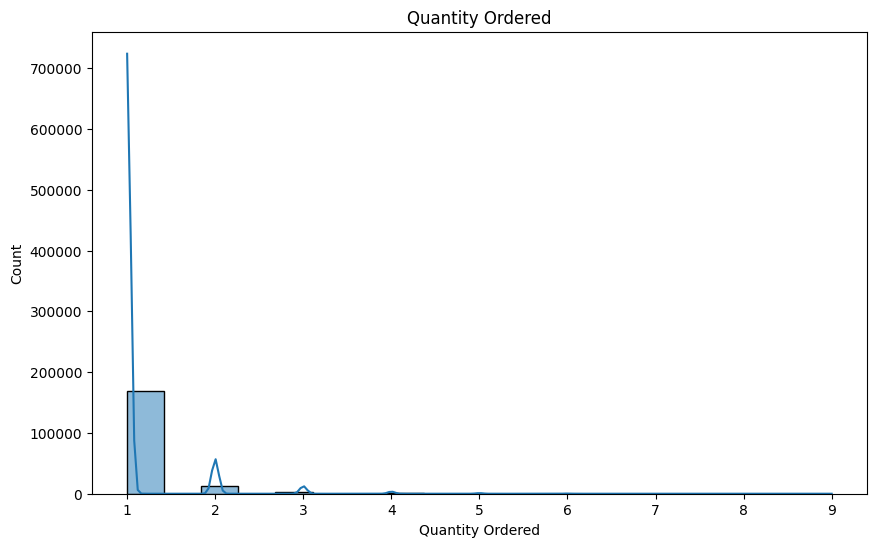

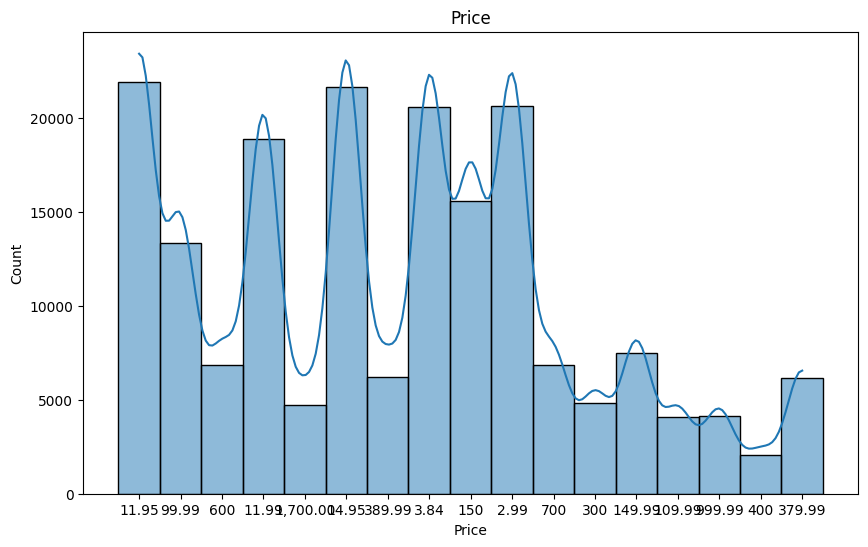

In [ ]:
numerical_cols = ["Quantity Ordered","Price"]
for col in numerical_cols:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

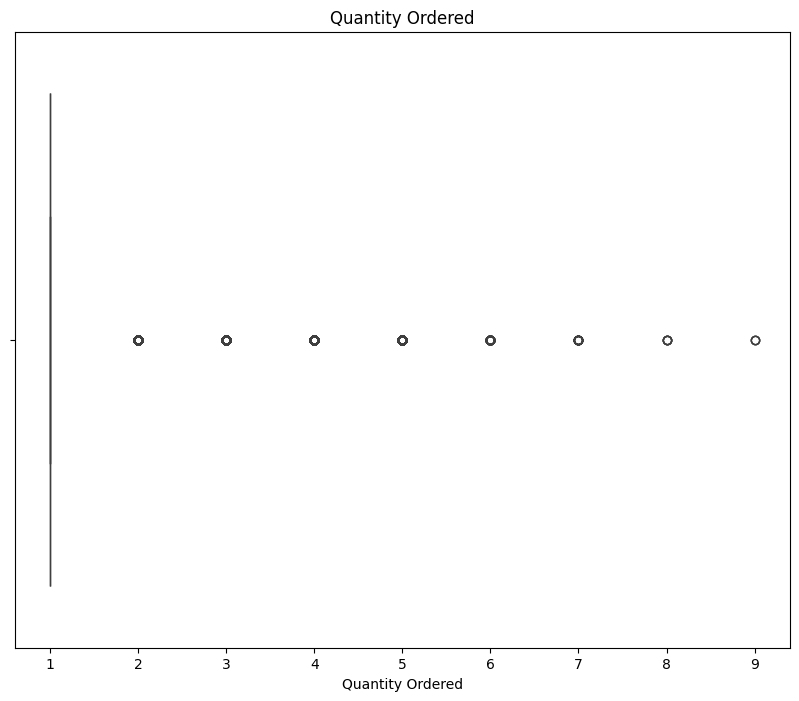

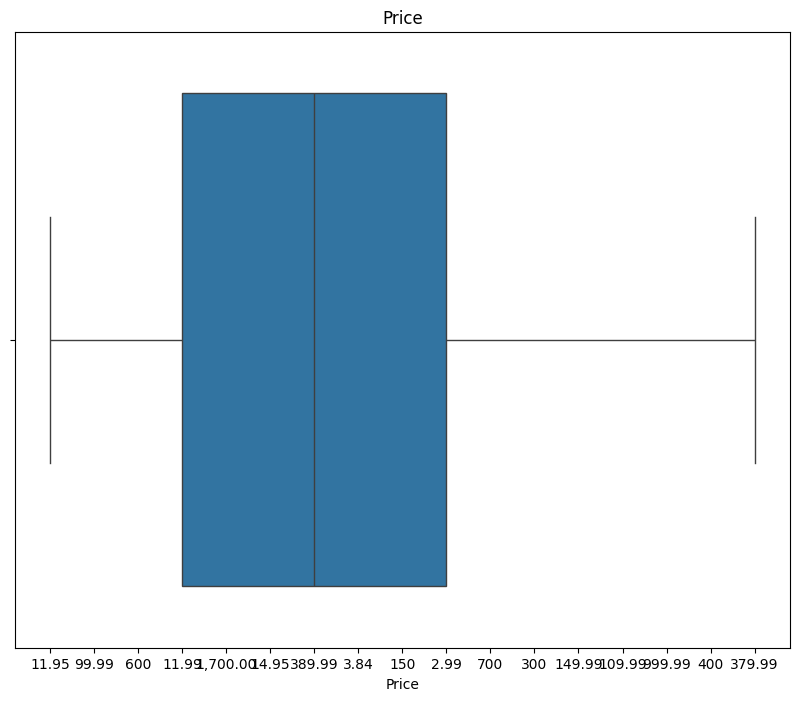

In [ ]:
#boxplots
for col in numerical_cols:
    plt.figure(figsize=(10,8))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**Next we will do correlation of different variables to see how they influence each other**

In [ ]:
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)

In [ ]:
#revenue creation
df["Revenue"] = df["Quantity Ordered"] * df["Price"]

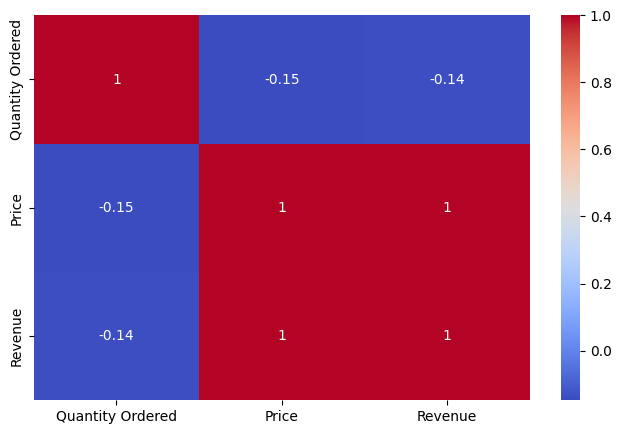

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["Quantity Ordered","Price","Revenue"]].corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

Lets proceed to product analysis

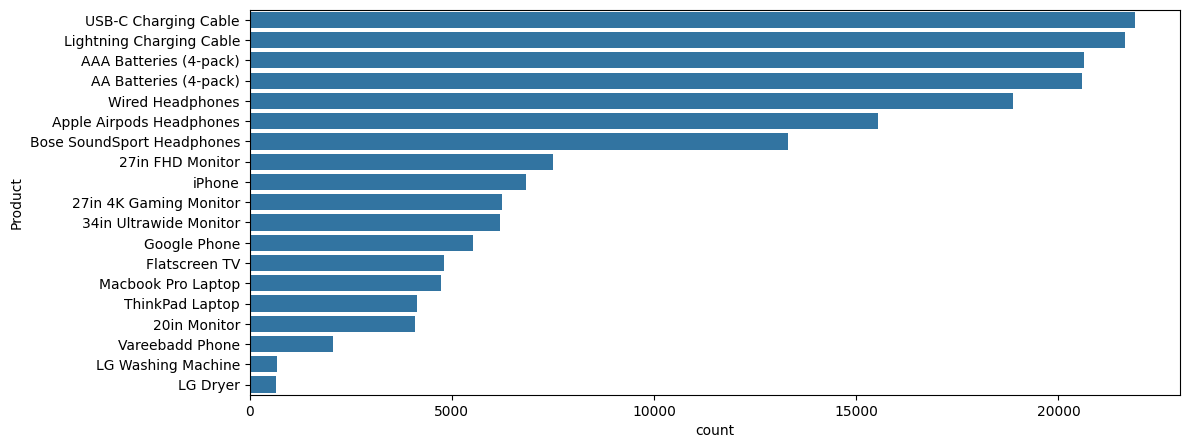

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,
              y="Product",
              order=df["Product"].value_counts().index)
plt.show()

Lets check for revenue generation by product and city

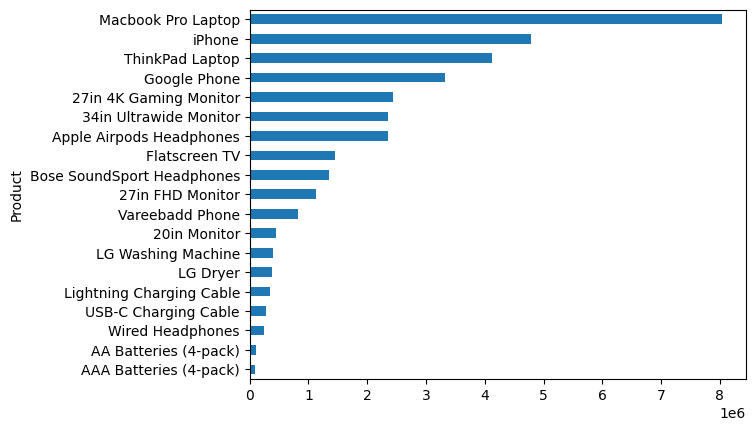

In [ ]:
#by product
product_sales = df.groupby("Product")["Revenue"].sum().sort_values()
product_sales.plot(kind="barh")
plt.show()

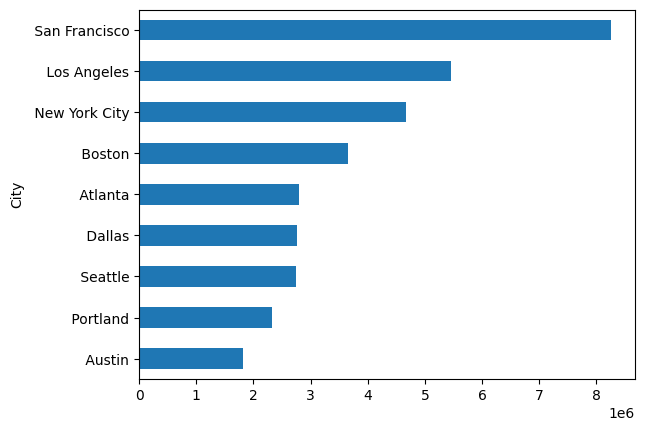

In [ ]:
#by City
city_sales = df.groupby("City")["Revenue"].sum().sort_values()
city_sales.plot(kind="barh")
plt.show()

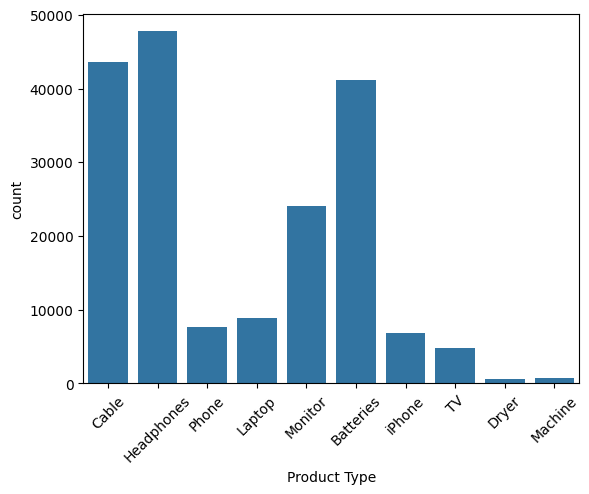

In [ ]:
#sales by product type
sns.countplot(data=df,
              x="Product Type")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Product Type'>

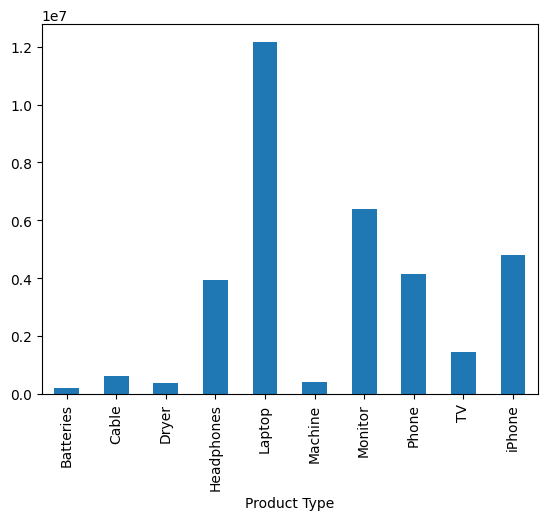

In [ ]:
#revenue by product type
df.groupby("Product Type")["Revenue"].sum().plot(kind="bar")

In [ ]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%Y-%m-%d"
)

In [ ]:
#monthly sales
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.month

/tmp/ipykernel_728/2828580905.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


<Axes: xlabel='Month'>

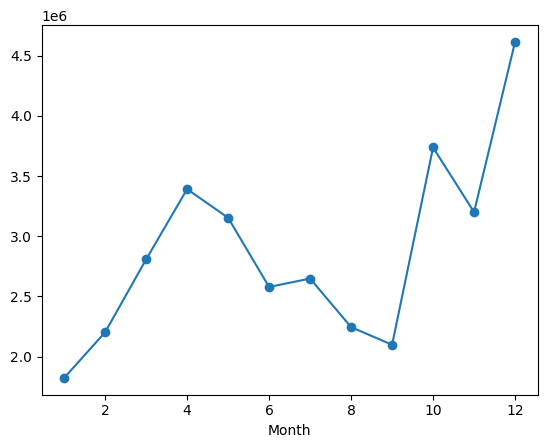

In [ ]:
df.groupby("Month")["Revenue"].sum().plot(marker="o")

In [ ]:
#hourly sales
df["Time"] = pd.to_datetime(df["Time"])
df["Hour"] = df["Time"].dt.hour

<Axes: xlabel='Hour'>

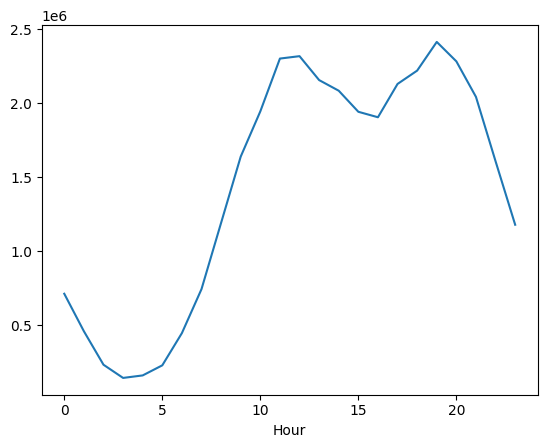

In [ ]:
df.groupby("Hour")["Revenue"].sum().plot()

In [ ]:
#by day of the week
df["Day"] = df["Order Date"].dt.day_name()

<Axes: xlabel='Day', ylabel='Revenue'>

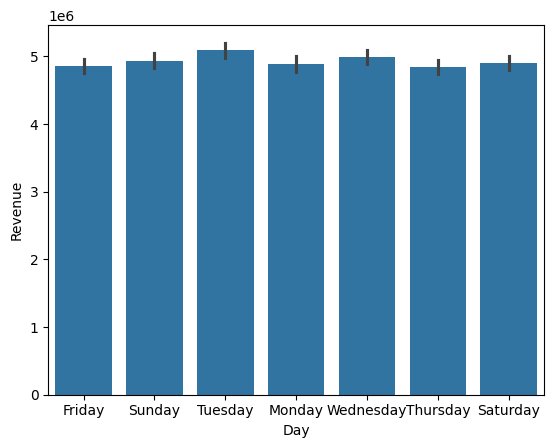

In [ ]:
sns.barplot(
    data=df,
    x="Day",
    y="Revenue",
    estimator=np.sum
)

**Feature Engineering**

Lets now move to the interesting part of the feature engineering


Since my target is Quantity Ordered, I will not create or use Revenue as an input feature because Revenue = Quantity Ordered * Price. Including Revenue would leak information from the target into the model and produce unrealistically good results.

In [ ]:
df["Revenue"] = df["Quantity Ordered"] * df["Price"]
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Weekday"] = df["Order Date"].dt.dayofweek
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

In [ ]:
#lets start by droping unneccesary variables
df = df.drop(columns=[
    "Order ID",
    "Order Date",
    "Time",
    "Purchase Address"
])

In [ ]:
#lets define our features and target
X = df.drop("Quantity Ordered", axis=1)
y = df["Quantity Ordered"]

In [ ]:
#lets do one-hot-encoding for the categorical columns
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns
preprocessor = ColumnTransformer([
("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols),
("num","passthrough",num_cols)])

In [ ]:
#train-test split
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [ ]:
#Usually we apply scaling after encoding so it is fit only on the training data,avoiding data leakage.
#In addition, scaling is needed for Linear Regression and especially later for PCA
scaler=StandardScaler()

**Model Training**

Lets now move to training our models. We will be training four models here:-

*  Random Forest
*  Gradient Boosting
*  XGBoost
*  Linear Regression

The models will be evaluated using the performance metrics : RMSE,MAE,
R²








In [ ]:
#Since we have categorical and numerical variables, let's preprocess them in one pipeline.
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [ ]:
#lets define the models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
#lets now train and evaluate all the models
baseline_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    baseline_results.append({
        "Model": name,
        "MAE": round(mae,3),
        "RMSE": round(rmse,3),
        "R²": round(r2,3)
    })

baseline_results = pd.DataFrame(baseline_results)

baseline_results.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
3,XGBoost,0.000,0.007,1.000
1,Random Forest,0.000,0.010,0.999
2,Gradient Boosting,0.001,0.016,0.999
0,Linear Regression,0.177,0.396,0.193


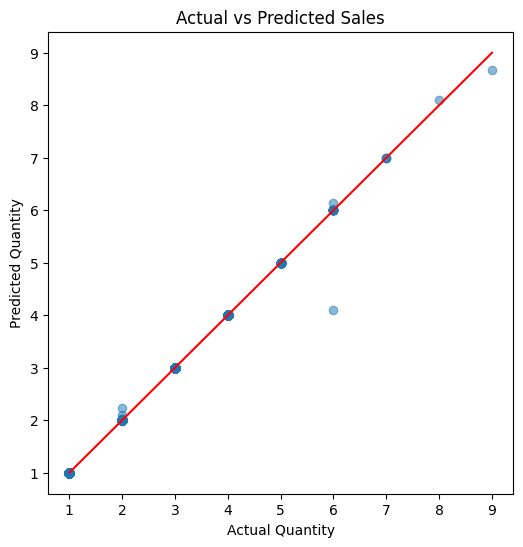

In [ ]:
#Lets Plot Actual vs Predicted
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

best_pipeline.fit(X_train, y_train)

pred = best_pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.5)
plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted Sales")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.show()

**Feature Selection**

We will compare three different feature selection methods:
*   SelectKBest
*   Random Forest Feature Importance
*   Recursive Feature Elimination (RFE)

Then we will use the best-performing feature subset for retraining.

In [ ]:
#Lets start by transforming the categorical variables
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

In [ ]:
#Select KBest
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(
    score_func=f_regression,
    k=15
)
X_train_kbest = selector.fit_transform(
    X_train_processed,
    y_train
)
X_test_kbest = selector.transform(
    X_test_processed
)
selected_features = feature_names[
    selector.get_support()
]
print(selected_features)

['num__Price' 'num__Revenue' 'cat__Product_27in FHD Monitor'
 'cat__Product_AA Batteries (4-pack)'
 'cat__Product_AAA Batteries (4-pack)'
 'cat__Product_Apple Airpods Headphones'
 'cat__Product_Bose SoundSport Headphones' 'cat__Product_iPhone'
 'cat__Product Type_Batteries' 'cat__Product Type_Cable'
 'cat__Product Type_Headphones' 'cat__Product Type_Laptop'
 'cat__Product Type_Monitor' 'cat__Product Type_Phone'
 'cat__Product Type_iPhone']


In [ ]:
#Retrain Models Using Selected Features
feature_selection_results = []
for name, model in models.items():
    model.fit(X_train_kbest, y_train)
    pred = model.predict(X_test_kbest)
    feature_selection_results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test,pred),3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test,pred)),3),
        "R²": round(r2_score(y_test,pred),3)
    })
feature_selection_results = pd.DataFrame(feature_selection_results)
feature_selection_results.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
1,Random Forest,0.000,0.008,1.000
3,XGBoost,0.000,0.006,1.000
2,Gradient Boosting,0.001,0.015,0.999
0,Linear Regression,0.177,0.396,0.193


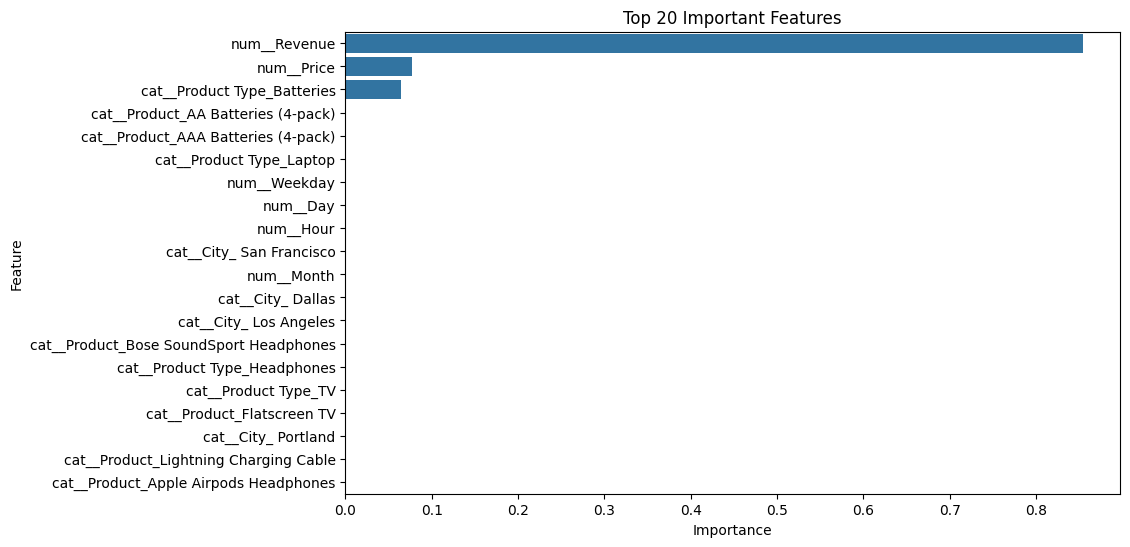

In [ ]:
#Random Forest Feature Importance
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_processed, y_train)
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    "Importance",
    ascending=False
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Important Features")
plt.show()

**Feature Extraction (PCA)**

Lets remember that PCA only works on numerical data, so we apply it after preprocessing and scaling.

In [ ]:
#Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_processed.toarray())
X_test_pca = pca.transform(X_test_processed.toarray())
print("Original Features :", X_train_processed.shape[1])
print("PCA Features :", X_train_pca.shape[1])

Original Features : 44
PCA Features : 19


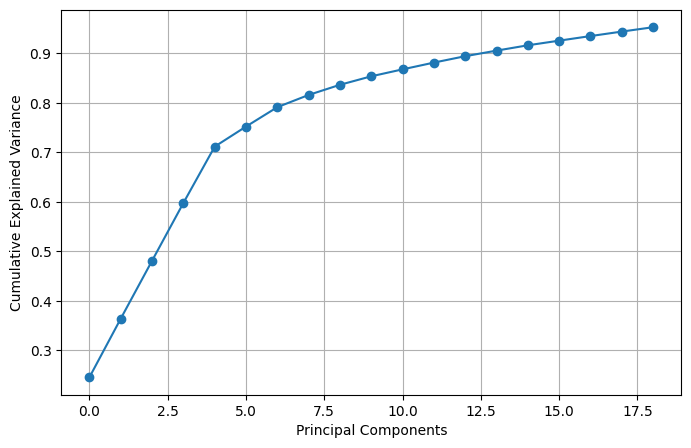

In [ ]:
#Variance
plt.figure(figsize=(8,5))
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [ ]:
#Lets retrain Models on PCA Features
pca_results = []
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    pred = model.predict(X_test_pca)
    pca_results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test,pred),3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test,pred)),3),
        "R²": round(r2_score(y_test,pred),3)
    })
pca_results = pd.DataFrame(pca_results)
pca_results.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
1,Random Forest,0.005,0.036,0.993
3,XGBoost,0.017,0.055,0.985
2,Gradient Boosting,0.062,0.146,0.891
0,Linear Regression,0.192,0.408,0.143


In [ ]:
#lets now do final comparison
baseline_results["Method"] = "Baseline"
feature_selection_results["Method"] = "Feature Selection"
pca_results["Method"] = "PCA"
comparison = pd.concat([
    baseline_results,
    feature_selection_results,
    pca_results
])
comparison = comparison[
    ["Method","Model","MAE","RMSE","R²"]
]
comparison.sort_values(
    ["Method","R²"],
    ascending=[True,False]
)

,Method,Model,MAE,RMSE,R²
3,Baseline,XGBoost,0.000,0.007,1.000
1,Baseline,Random Forest,0.000,0.010,0.999
2,Baseline,Gradient Boosting,0.001,0.016,0.999
0,Baseline,Linear Regression,0.177,0.396,0.193
1,Feature Selection,Random Forest,0.000,0.008,1.000
3,Feature Selection,XGBoost,0.000,0.006,1.000
2,Feature Selection,Gradient Boosting,0.001,0.015,0.999
0,Feature Selection,Linear Regression,0.177,0.396,0.193
1,PCA,Random Forest,0.005,0.036,0.993
3,PCA,XGBoost,0.017,0.055,0.985


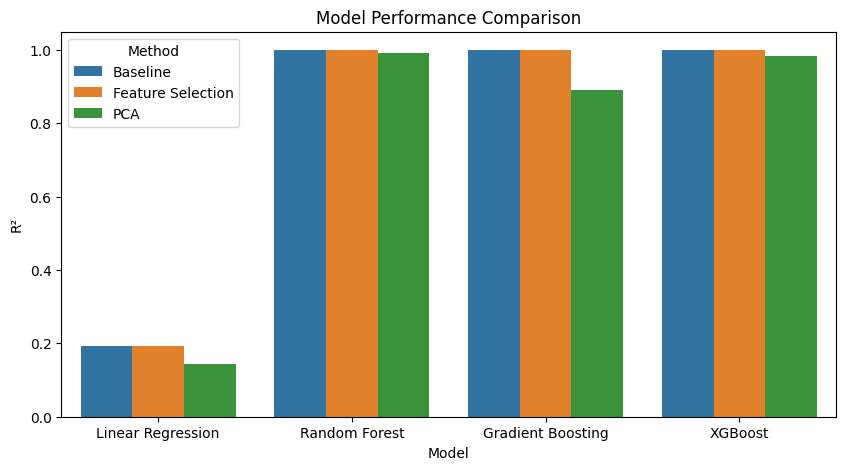

In [ ]:
#lets now have a comparison plot
plt.figure(figsize=(10,5))
sns.barplot(
    data=comparison,
    x="Model",
    y="R²",
    hue="Method"
)
plt.title("Model Performance Comparison")
plt.show()

In [ ]:
print(X.columns)

Index(['Product', 'Price', 'City', 'Product Type', 'Revenue', 'Month', 'Hour',
       'Day', 'Weekday'],
      dtype='object')


We can see that XGBoost and Random Forest performed better here.

**Challenges and Imporovements to be made**

1. When perfoming One -hot encoding, I realised it created new set of features. To avoid this in the future, we can use label encoding or skip this step entirely especially when dealing with tree-based algorithms.

2. To improve model performance, will do hyperparameter tuning or train the model on linear model and then boost it using boosting algorithms to see if performance improves.

3. Export this data to streamlit and create a prediction application.
